# BOB dataset - segmented using Freesurfer SAMSEG

- similar structure to notebook 3a  / 3b 
- Segmentation done using freesurfer - Samseg [link](https://surfer.nmr.mgh.harvard.edu/fswiki/Samseg)
- To do  - comparison of FD between previous segmentation methods

In [1]:
import ants
import subprocess
import nibabel as nib
import pandas as pd 
import utils as ut
from natsort import natsort_keygen
import numpy as np
from pathlib import Path
import subprocess
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import utils as ut
import re
import math
from scipy.stats import pearsonr
from scipy.stats import ttest_rel
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
import seaborn as sns

## Data  

In [3]:
#example file
# t1_scan = '../../Datasets/BOB/sub-116056/ses-3mo/anat/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w.nii.gz'
t1_scan = '/home/data/mri_datasets/bobs/sub-116056/ses-3mo/anat/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w.nii.gz'

Checking the data from the file  

In [4]:
im = nib.load(t1_scan)
print(im.header) 

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 182 218 182   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.  1.  1.  1.  0.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'6.0.4:ddd0a010'
aux_file        : b''
qform_code      : mni
sform_code      : mni
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 90.0
qoffset_y       : -126.0
qoffset_z       : -72.0
srow_x          : [-1.  0.  0

In [7]:
# csvpath = '../../Datasets/BOB/phenotype/sessions.tsv'
# ds_info = pd.read_csv(csvpath, sep ='\t')
# ds_info.head()

## Segmentations

Installation was done from [Freesurfer 7.4.1](https://surfer.nmr.mgh.harvard.edu/fswiki/rel7downloads), no additional installation or setup.  
6m30 on server.  

In [ ]:
inp = './sample/registered_0.nii.gz' 
out_dir = './sample/samseg_sample'


cmd_samseg = f'run_samseg --input {inp} --output {out_dir} --threads 36'
seg_process = subprocess.run([cmd_samseg], shell = True)

##----------------------------------------------
              Samsegment Options
##----------------------------------------------
output directory: ./sample/segmented_samseg.nii.gz
input images: ./sample/registered_0.nii.gz
modelSpecifications: {'FreeSurferLabels': [0, 165, 258, 16, 24, 8, 47, 15, 259, 3, 42, 7, 46, 41, 2, 63, 54, 18, 53, 44, 17, 31, 5, 85, 60, 28, 14, 26, 12, 51, 62, 58, 77, 4, 30, 43, 52, 11, 49, 13, 50, 10, 80, 72], 'atlasFileName': '/usr/local/freesurfer/7.4.1/average/samseg/20Subjects_smoothing2_down2_smoothingForAffine2/atlas_level2.txt.gz', 'names': ['Unknown', 'Skull', 'Soft_Nonbrain_Tissue', 'Brain-Stem', 'CSF', 'Left-Cerebellum-Cortex', 'Right-Cerebellum-Cortex', '4th-Ventricle', 'Fluid_Inside_Eyes', 'Left-Cerebral-Cortex', 'Right-Cerebral-Cortex', 'Left-Cerebellum-White-Matter', 'Right-Cerebellum-White-Matter', 'Right-Cerebral-White-Matter', 'Left-Cerebral-White-Matter', 'Right-choroid-plexus', 'Right-Amygdala', 'Left-Amygdala', 'Right-Hippocampus', 'Right-

L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNumber 0
     efficiency: 122.3519 %
     relative size: 21.5316 %
     setup time: 2.0164 sec
L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNumber 1
     efficiency: 130.4732 %
     relative size: 19.8805 %
     setup time: 1.1406 sec
L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNumber 2
     efficiency: 132.1393 %
     relative size: 19.5667 %
     setup time: 2.0713 sec
L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNum

L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNumber 0
     efficiency: 117.8863 %
     relative size: 22.4532 %
     setup time: 2.5046 sec
L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNumber 1
     efficiency: 116.8145 %
     relative size: 19.7736 %
     setup time: 1.4518 sec
L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNumber 2
     efficiency: 121.9833 %
     relative size: 18.7003 %
     setup time: 1.6038 sec
L-BFGS
BFGS-MaximumMemoryLength: 12
LineSearchMaximalDeformationIntervalStopCriterion: 0.001
MaximalDeformationStopCriterion: 0.001
MaximumNumberOfIterations: 20
Verbose: 0
blockNum

Note: Samseg computes and outputs the file samseg.stats, which contains the volumes of each labeled structure, e.g.: 

In [6]:
img = nib.load('sample/samseg_sample/seg.mgz')
array = img.get_fdata()
array.shape # note that the segmentation is smaller in volume

(202, 274, 217)

In [8]:
index_to_label = {}
with open('FreeSurferColorLUT.txt', 'r') as file:
    for line in file:
        # comments or empty
        if line.startswith('#') or not line.strip():
            continue

        parts = line.split()
        index = int(parts[0])
        label_name = ' '.join(parts[1:-4])
        index_to_label[index] = label_name

In [9]:
present_labels = np.unique(array)
# len(present_labels)
print("Detected labels :")
for i, lbl in enumerate(present_labels):
    label_name = index_to_label.get(lbl, 'Unknown')
    print(f"{int(lbl)}: {label_name}")
print(f"Detected {len(present_labels)} labels")

Detected labels :
0: Unknown
2: Left-Cerebral-White-Matter
3: Left-Cerebral-Cortex
4: Left-Lateral-Ventricle
5: Left-Inf-Lat-Vent
7: Left-Cerebellum-White-Matter
8: Left-Cerebellum-Cortex
10: Left-Thalamus
11: Left-Caudate
12: Left-Putamen
13: Left-Pallidum
14: 3rd-Ventricle
15: 4th-Ventricle
16: Brain-Stem
17: Left-Hippocampus
18: Left-Amygdala
24: CSF
26: Left-Accumbens-area
28: Left-VentralDC
30: Left-vessel
31: Left-choroid-plexus
41: Right-Cerebral-White-Matter
42: Right-Cerebral-Cortex
43: Right-Lateral-Ventricle
44: Right-Inf-Lat-Vent
46: Right-Cerebellum-White-Matter
47: Right-Cerebellum-Cortex
49: Right-Thalamus
50: Right-Caudate
51: Right-Putamen
52: Right-Pallidum
53: Right-Hippocampus
54: Right-Amygdala
58: Right-Accumbens-area
60: Right-VentralDC
62: Right-vessel
63: Right-choroid-plexus
72: 5th-Ventricle
77: WM-hypointensities
80: non-WM-hypointensities
85: Optic-Chiasm
165: Skull
258: Head-ExtraCerebral
259: Eye-Fluid
Detected 44 labels


## Loop for all volumes

In [41]:
# bob_win    = Path(r"../../Datasets/BOB")
# seg_win    = Path(r"../../Datasets/BOB_segmented")
bob = Path(r"/home/data/mri_datasets/bobs")
seg = Path(r"/home/data/mri_datasets/bobs/segmentations/samseg_BOB")
# root        = Path("../../Datasets/BOB")

inputs, outputs = [], []

# make directory for the output
seg.mkdir(parents=True, exist_ok=True)

# Collect scans & plan matches
for img in bob.rglob("*/anat/*T1w.nii*"):
    rel_path = img.relative_to(bob)
    out_img  = seg / "t1"/ img.name

    # ensure the parent folder for this output exists
    out_img.parent.mkdir(parents=True, exist_ok=True)

    inputs.append((str(img)))
    outputs.append((str(out_img)[:-7]))

In [43]:
# Write the two list files
in_list  = bob / "samseg_inputs.txt"
out_list = bob / "samseg_outputs.txt"

in_list.write_text("\n".join(inputs))
out_list.write_text("\n".join(outputs))

print(f"Wrote {len(inputs)} lines to:")
print("  ", in_list)
print("  ", out_list)


Wrote 71 lines to:
   /home/data/mri_datasets/bobs/samseg_inputs.txt
   /home/data/mri_datasets/bobs/samseg_outputs.txt


All loop. Done with samseg_loop.py 

In [1]:
# loop does something similar to the below, but for all images in the dataset
# for inp, out_dir in zip(inputs[:2], outputs[:2]):
#     cmd_samseg = f'run_samseg --input {inp} --output {out_dir} --threads 36'
#     seg_process = subprocess.run([cmd_samseg], shell = True)

### Subfolder for all masks

In [3]:
# Freesurfer label mapping
index_to_label = {}
with open('FreeSurferColorLUT.txt', 'r') as file:
    for line in file:
        # comments or empty
        if line.startswith('#') or not line.strip():
            continue

        parts = line.split()
        index = int(parts[0])
        label_name = ' '.join(parts[1:-4])
        index_to_label[index] = label_name

In [ ]:
# these are DIRs
outputs

In [44]:
# Loop through each segmented file
for p in outputs:
    # create a segmentation_outputs folder alongside the samseg outputs
    sess_dir  = Path(f"{p}") / "segmentation_outputs"
    print(sess_dir)

/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-645257_ses-4mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-455675_ses-6mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-801091_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-940808_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-295081_ses-5mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116845_ses-6mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116845_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-552990_ses-8mo_space-INFANTMNIacpc_T1w/segmentation_outputs
/home/data/mri_datasets/bobs/seg

In [48]:
# Loop through each segmented file
for p in outputs:
    # create a segmentation_outputs folder alongside the samseg outputs
    sess_dir  = Path(f"{p}") / "segmentation_outputs"
    sess_dir.mkdir(exist_ok=True)

    # load the segmentation volume
    vol_path = f"{p}/seg.mgz"
    img   = nib.load(vol_path)
    data  = img.get_fdata().astype(int)
    labels = np.unique(data)
    labels = labels[labels != 0]              # skip background label 0

    print(f"[{Path(p).stem}] saving masks for labels: {labels}")

    # write one binary mask per label
    for lbl in labels:
        name = index_to_label.get(int(lbl))
        if not name:
            print(f"skipping unknown label {lbl}")
            continue

        mask = (data == lbl).astype(np.uint8)
        mask_img = nib.Nifti1Image(mask, img.affine, img.header)
        mask_fp  = sess_dir / f"{lbl:03d}_{name}.nii.gz"
        nib.save(mask_img, str(mask_fp))
        print(f"wrote {mask_fp}")
        # print(f"wrote {mask_fp.name}")


[sub-645257_ses-4mo_space-INFANTMNIacpc_T1w] saving masks for labels: [  2   3   4   5   7   8  10  11  12  13  14  15  16  17  18  24  26  28
  30  31  41  42  43  44  46  47  49  50  51  52  53  54  58  60  62  63
  72  77  80  85 165 258]
wrote /home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-645257_ses-4mo_space-INFANTMNIacpc_T1w/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz
wrote /home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-645257_ses-4mo_space-INFANTMNIacpc_T1w/segmentation_outputs/003_Left-Cerebral-Cortex.nii.gz
wrote /home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-645257_ses-4mo_space-INFANTMNIacpc_T1w/segmentation_outputs/004_Left-Lateral-Ventricle.nii.gz
wrote /home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-645257_ses-4mo_space-INFANTMNIacpc_T1w/segmentation_outputs/005_Left-Inf-Lat-Vent.nii.gz
wrote /home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-645257_ses-4mo_space-INFANTMNIacpc_T1w/segmentatio

## Volume

In [55]:
outputs[0]

'/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-645257_ses-4mo_space-INFANTMNIacpc_T1w'

In [58]:
def parse_filename_metadata(path_str):
    # Example: sub-116056_ses-3mo_space-INFANTMNIacpc_T1w
    name = Path(path_str).stem
    parts = name.split("_")
    participant_id = next((p for p in parts if p.startswith("sub-")), "")
    session_id = next((p for p in parts if p.startswith("ses-")), "")
    return name, participant_id, session_id

In [59]:
parse_filename_metadata(outputs[0])

('sub-645257_ses-4mo_space-INFANTMNIacpc_T1w', 'sub-645257', 'ses-4mo')

In [98]:
# Loop through each stat 
all_data = []
for p in outputs:
    stats_dict = {}
    stats_file = Path(f"{p}") / "samseg.stats"
    with stats_file.open("r") as f:
        for line in f:
            # print(line.strip().split(" "))
            if line.startswith("# Measure"):
                parts = line.strip().split()    
                if len(parts) >= 4:
                    region = parts[2].rstrip(",")  # remove trailing comma
                    value = float(parts[3].rstrip(","))
                    stats_dict[region] = value

                    filename, participant_id, session_id = parse_filename_metadata(p)
                    stats_dict["file"] = filename
                    stats_dict["participant_id"] = participant_id
                    stats_dict["session_id"] = session_id
    all_data.append(stats_dict)

all_volumes = pd.DataFrame(all_data)
# Reorder columns: file first, then stats, then metadata
cols = ['file'] + [col for col in all_volumes.columns if col not in ('file')]
all_volumes = all_volumes[cols]
all_volumes.head()

,file,Unknown,participant_id,session_id,Skull,Soft_Nonbrain_Tissue,Brain-Stem,CSF,Left-Cerebellum-Cortex,Right-Cerebellum-Cortex,...,Left-vessel,Right-Lateral-Ventricle,Right-Pallidum,Left-Caudate,Right-Thalamus,Left-Pallidum,Right-Caudate,Left-Thalamus,non-WM-hypointensities,5th-Ventricle
0,sub-645257_ses-4mo_space-INFANTMNIacpc_T1w,447005.299137,sub-645257,ses-4mo,239760.035103,599573.487274,10273.110393,287558.981559,38141.972752,37438.416260,...,244.456209,8839.856969,1205.270540,2075.324732,7475.817710,1223.760139,2057.377396,8203.328818,97.926706,47.089736
1,sub-455675_ses-6mo_space-INFANTMNIacpc_T1w,506831.359599,sub-455675,ses-6mo,299932.081854,692260.844115,20016.444874,350769.622395,42155.190510,47836.220670,...,240.737672,12194.529191,1312.251642,2794.837493,8999.033386,1465.529575,2976.787791,9661.705357,374.566085,40.641499
2,sub-801091_ses-3mo_space-INFANTMNIacpc_T1w,444028.994024,sub-801091,ses-3mo,280405.583941,608848.973625,14030.051414,322240.560400,47390.092309,50806.393970,...,155.760327,8126.406504,1292.993036,2268.518987,9193.386804,1346.245583,3350.309147,8754.834659,200.460747,76.077504
3,sub-940808_ses-3mo_space-INFANTMNIacpc_T1w,440961.554680,sub-940808,ses-3mo,258804.990510,612167.573515,14709.628066,298282.144130,30485.266846,36202.027465,...,163.565235,9349.611815,1385.509021,2006.167992,7228.214050,1266.320662,2909.017188,7044.762276,167.695706,8.724335
4,sub-295081_ses-5mo_space-INFANTMNIacpc_T1w,440936.172081,sub-295081,ses-5mo,270944.150719,616888.882345,15392.021179,306479.782872,27732.795803,29768.681032,...,206.147548,12459.368987,1153.217881,2210.945275,7697.273766,1099.628979,2555.878727,7920.135834,542.634867,9.769389


In [74]:
all_volumes.columns

Index(['file', 'Unknown', 'Skull', 'Soft_Nonbrain_Tissue', 'Brain-Stem', 'CSF',
       'Left-Cerebellum-Cortex', 'Right-Cerebellum-Cortex', '4th-Ventricle',
       'Fluid_Inside_Eyes', 'Left-Cerebral-Cortex', 'Right-Cerebral-Cortex',
       'Left-Cerebellum-White-Matter', 'Right-Cerebellum-White-Matter',
       'Right-Cerebral-White-Matter', 'Left-Cerebral-White-Matter',
       'Right-choroid-plexus', 'Right-Amygdala', 'Left-Amygdala',
       'Right-Hippocampus', 'Right-Inf-Lat-Vent', 'Left-Hippocampus',
       'Left-choroid-plexus', 'Left-Inf-Lat-Vent', 'Optic-Chiasm',
       'Right-VentralDC', 'Left-VentralDC', '3rd-Ventricle',
       'Left-Accumbens-area', 'Left-Putamen', 'Right-Putamen', 'Right-vessel',
       'Right-Accumbens-area', 'WM-hypointensities', 'Left-Lateral-Ventricle',
       'Left-vessel', 'Right-Lateral-Ventricle', 'Right-Pallidum',
       'Left-Caudate', 'Right-Thalamus', 'Left-Pallidum', 'Right-Caudate',
       'Left-Thalamus', 'non-WM-hypointensities', '5th-Ventric

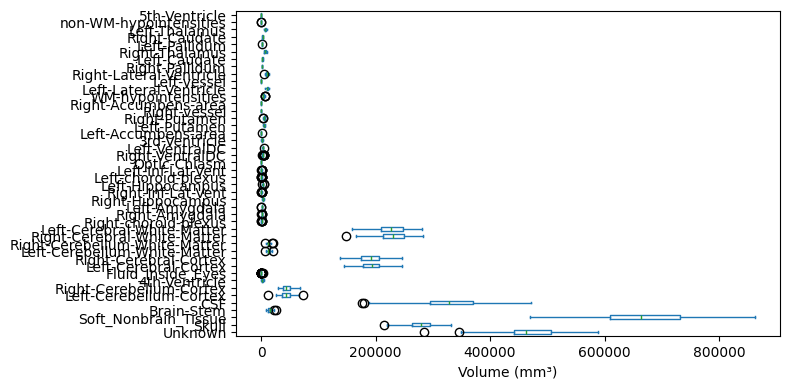

In [99]:
fig, ax = plt.subplots(figsize=(8, 4))
all_volumes.plot.box(vert=False, ax=ax)
ax.set_xlabel('Volume (mm³)')
plt.tight_layout()
plt.show()

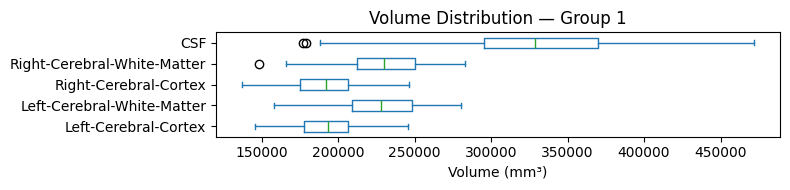

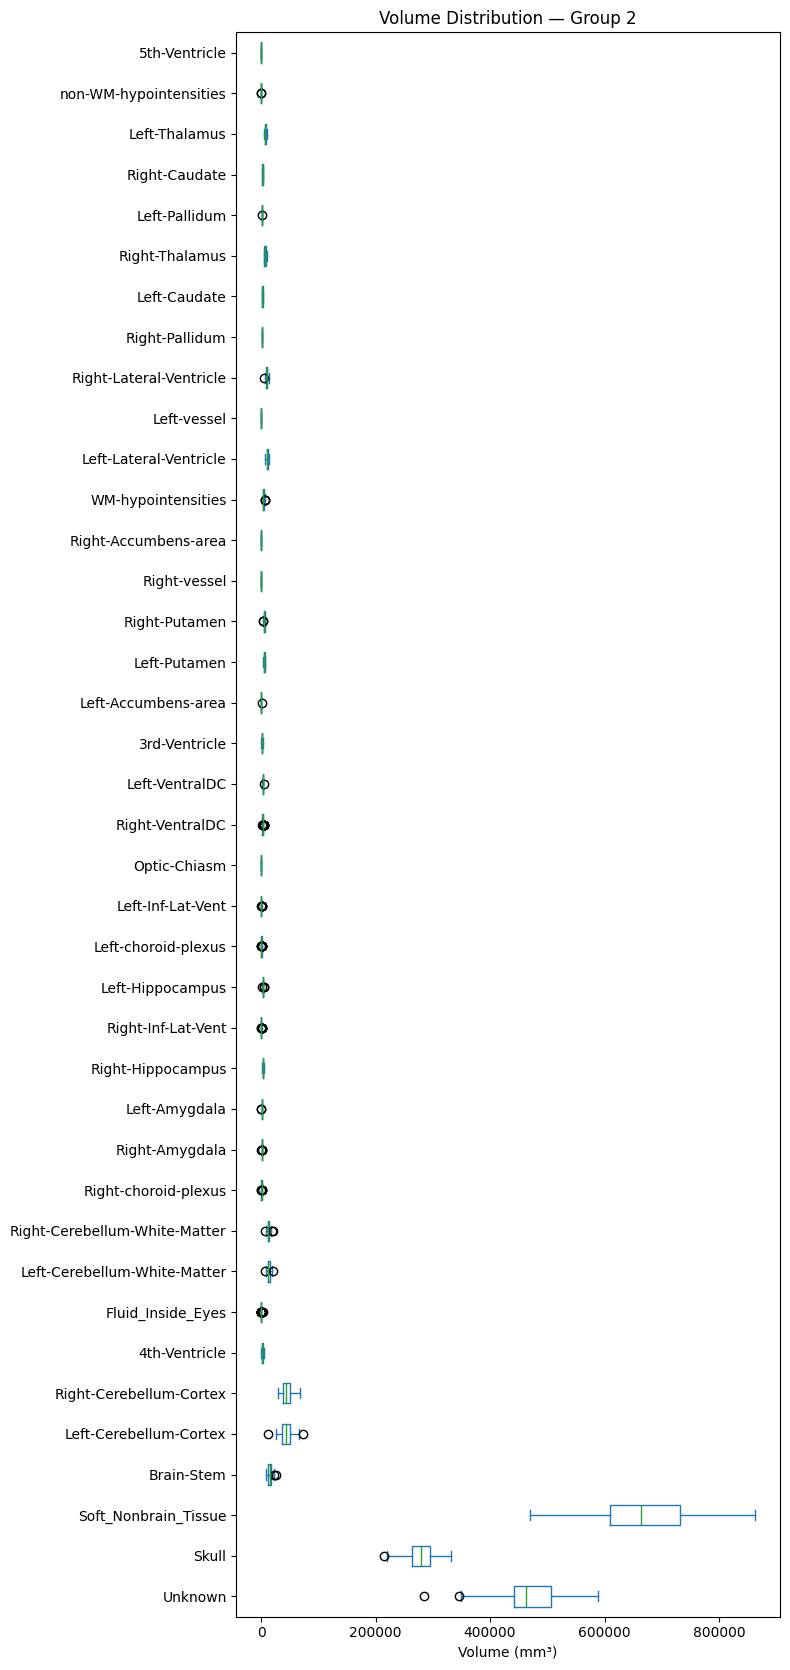

In [100]:
# group1 = [
#     'total intracranial'
# ]

group2 = [
    'Left-Cerebral-Cortex',
    'Left-Cerebral-White-Matter',
    'Right-Cerebral-Cortex',
    'Right-Cerebral-White-Matter',
    'CSF'
]

all_cols = list(all_volumes.columns)
group3 = [col for col in all_cols if col not in  group2]

# groups = [group1, group2, group3]
groups = [group2, group3]

for idx, cols in enumerate(groups, 1):
    fig, ax = plt.subplots(figsize=(8, len(cols)*0.4))
    all_volumes[cols].plot.box(vert=False, ax=ax)
    ax.set_xlabel('Volume (mm³)')
    ax.set_title(f'Volume Distribution — Group {idx}')
    plt.tight_layout()
    plt.show()

In [101]:
csvpath = 'sessions.tsv'
ds_info = pd.read_csv(csvpath, sep ='\t')
ds_info.head()

,participant_id,session_id,age,gestational_age_at_birth,sex
0,sub-116056,ses-3mo,3.6,40.4,Male
1,sub-116845,ses-3mo,3.6,37.7,Female
2,sub-116845,ses-6mo,6.5,37.7,Female
3,sub-176427,ses-5mo,5.0,41.7,Female
4,sub-198202,ses-5mo,5.9,40.1,Male


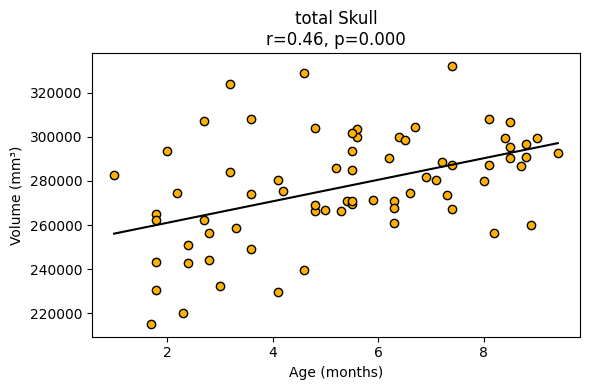

In [104]:
df_vol_merged = all_volumes.merge(
    ds_info,
    on=['participant_id', 'session_id'],
    how='left'
)

vols = df_vol_merged['Skull'].values
ages = df_vol_merged['age'].values

# linear fit + stats
slope, intercept = np.polyfit(ages, vols, 1)
x_line = np.linspace(ages.min(), ages.max(), 100)
y_line = slope * x_line + intercept
r_val, p_val = pearsonr(ages, vols)

plt.figure(figsize=(6,4))
plt.scatter(ages, vols, c='#FFB000', edgecolor='k')
plt.plot(x_line, y_line, color='black')
plt.xlabel("Age (months)")
plt.ylabel("Volume (mm³)")
plt.title(f"total Skull\nr={r_val:.2f}, p={p_val:.3f}")
plt.tight_layout()
plt.show()

## Fractal dimension calculation

Had to convert the output from mgz to nifti : 
mri_convert, see convert.sh

In [88]:
data_folder = Path("/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/")

fd_results = []

# loop over whole-brain dseg files
for p in outputs[:1]:
    dseg = Path(f"{p}") / "seg.nii.gz"
    filename, participant_id, session_id = parse_filename_metadata(p)
    print(f"processing {dseg.parent.name}")
    # print(f"filename: {filename}, participant_id: {participant_id}, session_id: {session_id}")

    # whole-brain FD
    fd, (mfs, Mfs), _ = ut.fractal_analysis(str(dseg), verbose=False)
    fd_results.append({
        'participant_id': participant_id,
        'session_id':    session_id,
        'label':         None,
        'name':          'whole_brain',
        'fd':            fd,
        'min_box_size':  mfs,
        'max_box_size':  Mfs
    })

    # per-mask FD
    mask_dir = dseg.parent / "segmentation_outputs"
    if not mask_dir.exists():
        print(f" no masks found for {dseg.stem}, skipping masks")
        continue

    for mask_fp in mask_dir.glob("*.nii.gz"):
        # extract label and name from filename "###_LabelName.nii.gz"
        stem = mask_fp.stem
        lbl_str, name = stem.split("_", 1)
        lbl = int(lbl_str)

        fd, (mfs, Mfs), _ = ut.fractal_analysis(str(mask_fp), verbose=False)
        fd_results.append({
            'participant_id': participant_id,
            'session_id':    session_id,
            'label':         lbl,
            'name':          name,
            'fd':            fd,
            'min_box_size':  mfs,
            'max_box_size':  Mfs
        })


processing sub-645257_ses-4mo_space-INFANTMNIacpc_T1w
FD automatically selected: 2.8585
FD automatically selected: 2.1719
FD automatically selected: 2.3543
FD automatically selected: 2.079
FD automatically selected: 1.5872
FD automatically selected: 1.2347
FD automatically selected: 1.3533
FD automatically selected: 1.5519
FD automatically selected: 1.9814
FD automatically selected: 1.9668
FD automatically selected: 2.288
FD automatically selected: 0.6443
FD automatically selected: 2.1526
FD automatically selected: 1.9
FD automatically selected: 2.4659
FD automatically selected: 1.8626
FD automatically selected: 2.3615
FD automatically selected: 1.1004
FD automatically selected: 2.0943
FD automatically selected: 1.9351
FD automatically selected: 1.3116
FD automatically selected: 2.4832
FD automatically selected: 1.9145
FD automatically selected: 1.8699
FD automatically selected: 2.2623
FD automatically selected: 1.9537
FD automatically selected: 2.2861
FD automatically selected: 2.2056

In [90]:
df_fd = pd.DataFrame(fd_results)
df_fd.head()

,participant_id,session_id,label,name,fd,min_box_size,max_box_size
0,sub-645257,ses-4mo,NaN,whole_brain,2.8585,1.0,16.0
1,sub-645257,ses-4mo,51.0,Right-Putamen.nii,2.1719,1.0,16.0
2,sub-645257,ses-4mo,42.0,Right-Cerebral-Cortex.nii,2.3543,1.0,32.0
3,sub-645257,ses-4mo,43.0,Right-Lateral-Ventricle.nii,2.0790,1.0,16.0
4,sub-645257,ses-4mo,85.0,Optic-Chiasm.nii,1.5872,1.0,16.0


In [106]:
df_fd = df_fd[
    ['participant_id','session_id','label','name','fd','min_box_size','max_box_size']
]

df_fd_merged = df_fd.merge(
    ds_info,
    on=['participant_id', 'session_id'],
    how='left'
)

# remove any trailing ".nii"
df_fd_merged['name'] = (
    df_fd_merged['name']
      .str.replace(".nii", "")
)

df_fd_merged.head()
df_fd_merged.to_csv('BOB_fd_results_samseg_SAMPLE.csv', index=False)

Whole batch ran with samseg_fd_loop.py

### EDA

In [2]:
df_fd_merged = pd.read_csv('outputs/BOB_fd_results_samseg.csv')

In [3]:
n_missing = df_fd_merged['fd'].isna().sum()
print(f"Total missing FD values: {n_missing}")

Total missing FD values: 0


In [4]:
counts = df_fd_merged['name'].value_counts().reset_index()
counts.columns = ['name', 'count']
counts

,name,count
0,whole_brain,71
1,Right-Putamen,71
2,Right-Cerebral-Cortex,71
3,Right-Lateral-Ventricle,71
4,Optic-Chiasm,71
5,Left-Inf-Lat-Vent,71
6,Right-Accumbens-area,71
7,Left-Hippocampus,71
8,Left-Thalamus,71
9,Right-Hippocampus,71


### sorted FD plots

In [5]:
# df_fd_merged = pd.read_csv('BOB_fd_results_freesurfer-seg.csv')

In [6]:
def assign_color(label_name):
    if 'Left' in label_name:
        return '#648FFF'
    elif 'Right' in label_name:
        return '#DC267F'
    elif 'whole_brain' in label_name:
        return '#FFB000'
    else:
        return 'grey'

In [7]:
# Determine sort order by median FD descending
region_order = (
    df_fd_merged.groupby('name')['fd']
      .median()
      .sort_values(ascending=False)
      .index
      .tolist()
)

colors = [assign_color(r) for r in region_order]

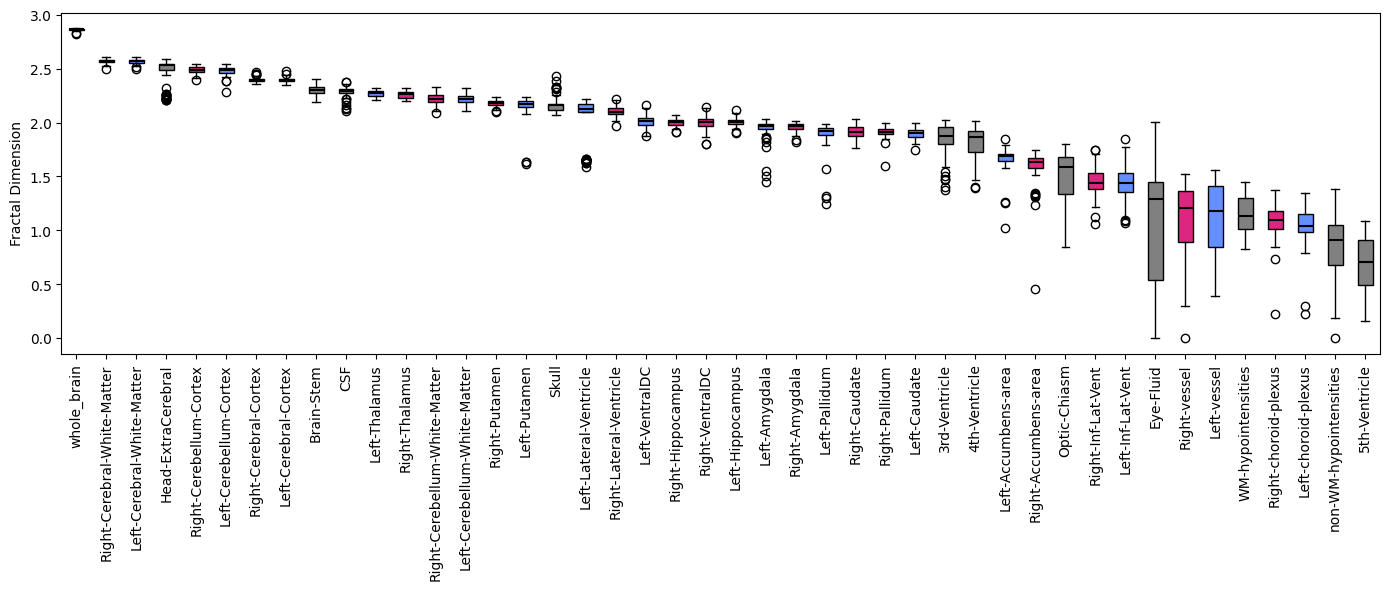

In [8]:
# Prepare data and colors
data_to_plot = [df_fd_merged[df_fd_merged['name'] == r]['fd'] for r in region_order]

plt.figure(figsize=(14, 6))
bp = plt.boxplot(data_to_plot,
                 tick_labels=region_order,
                 patch_artist=True,
                 showfliers=True,
                 medianprops=dict(color='black', linewidth=1.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(rotation=90)
plt.ylabel("Fractal Dimension")
plt.tight_layout()
plt.show()

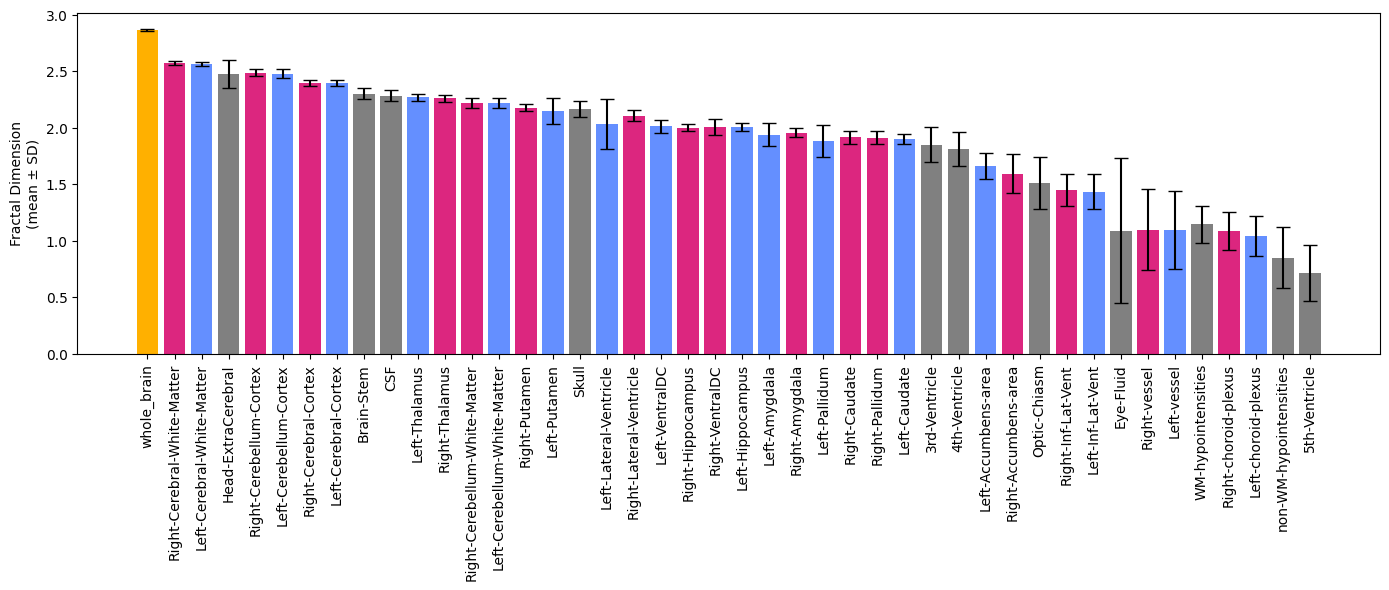

In [9]:
means = []
stds  = []
for r in region_order:
    vals = df_fd_merged.loc[df_fd_merged['name'] == r, 'fd']
    means.append(vals.mean())
    stds.append(vals.std())

x = np.arange(len(region_order))
plt.figure(figsize=(14, 6))
bars = plt.bar(x, means,
               yerr=stds,
               capsize=5,
               color=colors)
plt.xticks(x, region_order, rotation=90)
plt.ylabel("Fractal Dimension\n(mean ± SD)")
plt.tight_layout()
plt.show()

### side comparison

In [10]:
# Helper for Cohen's d (paired)
def cohen_d_paired(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

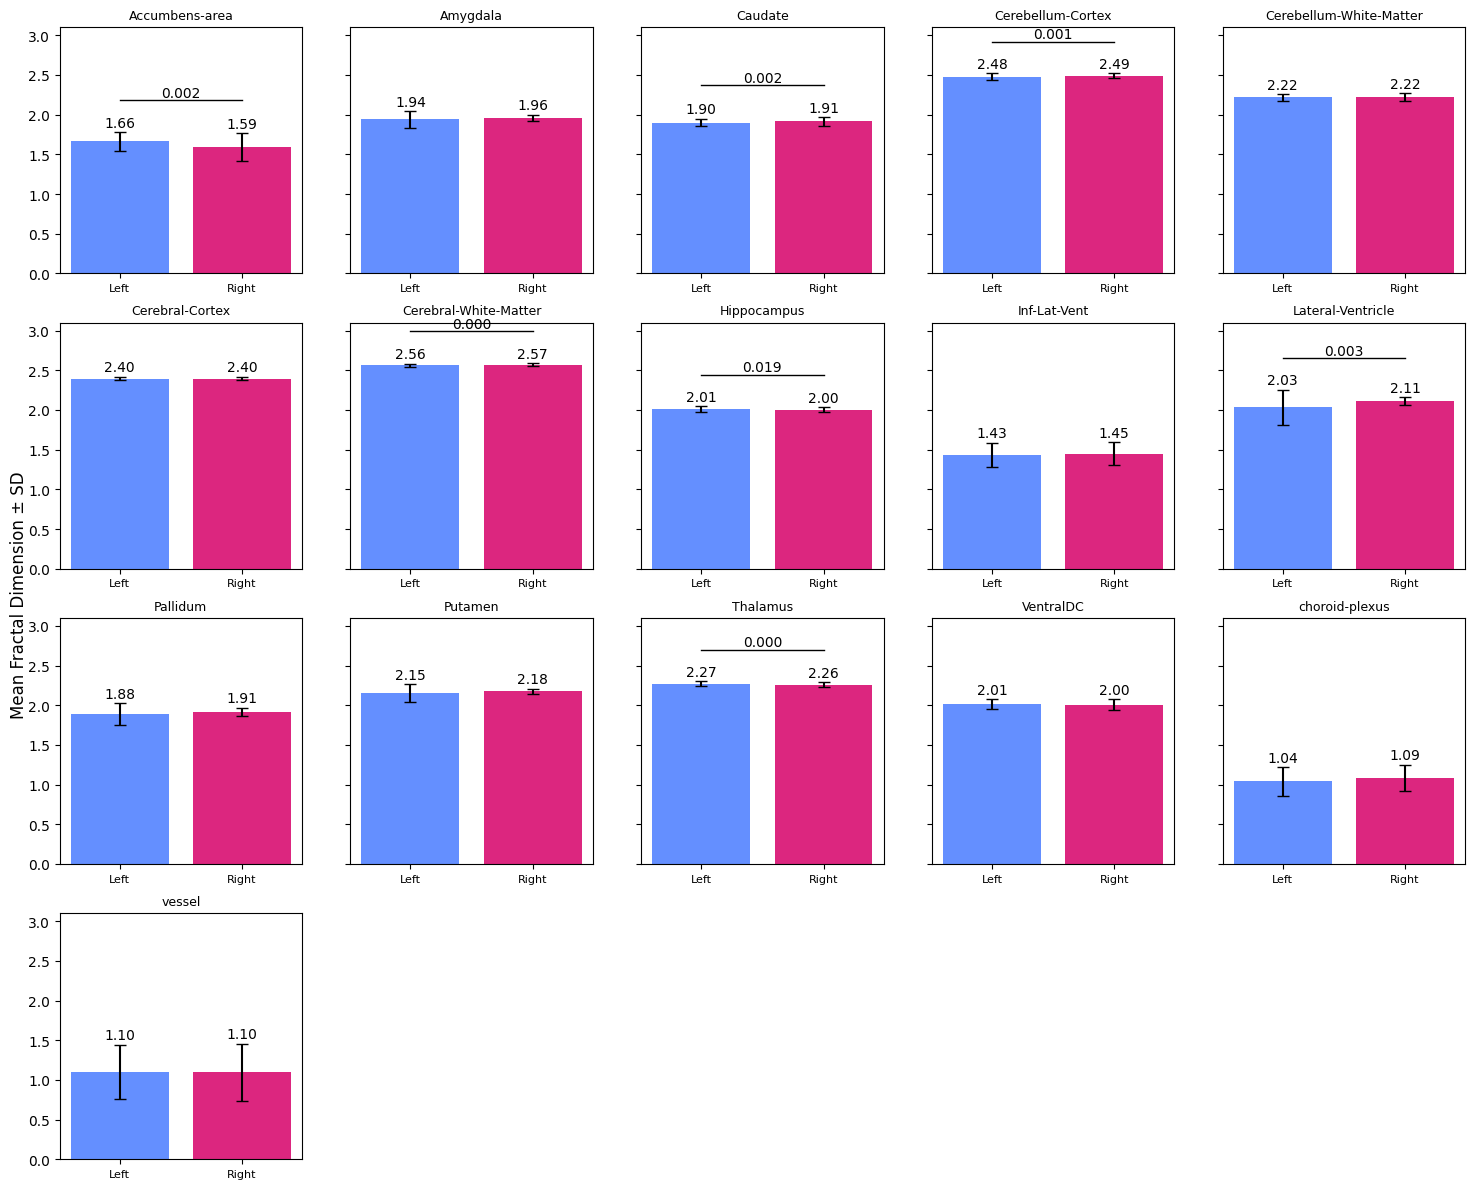

,name,FD (Left),FD (Right),FD (diff),n,p-val,d
0,Accumbens-area,1.66 ± 0.12,1.59 ± 0.17,0.07 ± 0.18,71,0.002,0.38
1,Amygdala,1.94 ± 0.10,1.96 ± 0.04,-0.02 ± 0.08,71,0.069,-0.22
2,Caudate,1.90 ± 0.05,1.91 ± 0.05,-0.01 ± 0.04,71,0.002,-0.38
3,Cerebellum-Cortex,2.48 ± 0.04,2.49 ± 0.03,-0.01 ± 0.03,71,0.001,-0.40
4,Cerebellum-White-Matter,2.22 ± 0.04,2.22 ± 0.05,-0.00 ± 0.02,71,0.308,-0.12
5,Cerebral-Cortex,2.40 ± 0.02,2.40 ± 0.02,-0.00 ± 0.01,71,0.981,-0.00
6,Cerebral-White-Matter,2.56 ± 0.02,2.57 ± 0.02,-0.01 ± 0.01,71,0.000,-0.78
7,Hippocampus,2.01 ± 0.04,2.00 ± 0.03,0.01 ± 0.02,71,0.019,0.28
8,Inf-Lat-Vent,1.43 ± 0.16,1.45 ± 0.14,-0.02 ± 0.09,71,0.172,-0.16
9,Lateral-Ventricle,2.03 ± 0.22,2.11 ± 0.05,-0.08 ± 0.20,71,0.003,-0.37


In [11]:
# Copy and clean
df = df_fd_merged.copy()
df['name'] = df['name'].str.replace(r'\.nii(\.gz)?$', '', regex=True)
df['base_name'] = df['name'].apply(lambda x: re.sub(r'^(Left-|Right-)', '', x))
df['side'] = df['name'].apply(lambda x: 'Left' if x.startswith('Left-') else 'Right')

# Identify true pairs
side_counts = df.groupby('base_name')['side'].nunique()
paired_bases = side_counts[side_counts == 2].index.tolist()
df_paired = df[df['base_name'].isin(paired_bases)]

# Compute statistics table
stats_list = []
for base in paired_bases:
    sub = df_paired[df_paired['base_name'] == base]
    pt = sub.pivot_table(index=['participant_id','session_id'],
                         columns='side', values='fd').dropna()
    left = pt['Left']
    right = pt['Right']
    diff = left - right

    mean_diff = diff.mean()
    sd_diff   = diff.std(ddof=1)
    t_stat, p_val = ttest_rel(left, right)
    d_val = cohen_d_paired(left, right)
    
    stats_list.append({
        'name': base,
        'FD (Left)': f"{left.mean():.2f} ± {left.std(ddof=1):.2f}",
        'FD (Right)': f"{right.mean():.2f} ± {right.std(ddof=1):.2f}",
        'FD (diff)': f"{mean_diff:.2f} ± {sd_diff:.2f}",
        'n': len(diff),
        'p-val': f"{p_val:.3f}",
        'd': f"{d_val:.2f}"
    })

df_stats = pd.DataFrame(stats_list)

# Bar plot of mean ± SD with significance stars
# First, compute mean and sd per side
agg = df_paired.groupby(['base_name','side'])['fd'] \
               .agg(mean='mean', sd='std') \
               .reset_index()

n_pairs = len(paired_bases)
ncols   = 5
nrows   = math.ceil(n_pairs / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3), sharey=True)
axes = axes.flatten()

for ax, base in zip(axes, paired_bases):
    sub = agg[agg['base_name'] == base].set_index('side').loc[['Left','Right']].reset_index()
    x = np.arange(2)
    means = sub['mean'].values
    stds  = sub['sd'].values
    full_names = sub['side'] + '-' + base
    colors = [assign_color(fn) for fn in full_names]
    
    # Plot bars
    ax.bar(x, means, yerr=stds, capsize=4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['side'], fontsize=8)
    ax.set_title(base, fontsize=9)
    
    # Annotate mean values
    for xi, m, sd in zip(x, means, stds):
        ax.text(xi, m + sd + 0.03, f"{m:.2f}", ha='center', va='bottom', fontsize=10)
    
    # Significance star
    row = df_stats[df_stats['name'] == base].iloc[0]
    p = float(row['p-val'])

    if p < 0.05:
        # coordinates
        y0 = max(means + stds) + 0.4           # base height of line
        # draw horizontal line 
        ax.plot([x[0], x[1]], [y0, y0], color='black', linewidth=1)
        # add the star centered
        ax.text((x[0]+x[1])/2, y0 + 0.005, f"{p:.3f}",
                ha='center', va='bottom', fontsize=10)

# Turn off extras
for ax in axes[n_pairs:]:
    ax.axis('off')

fig.supylabel("Mean Fractal Dimension ± SD")
plt.setp(axes, ylim=(0, 3.1))
plt.tight_layout()
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

df_stats


Display only the significant differences, after aplying Bonferroni correction for multiple comparison:

In [12]:
# number of paired tests
n_tests = len(df_stats)
alpha_corr = 0.05 / n_tests

df_stats['p_nominal'] = df_stats['p-val'].astype(float)
df_stats['sign_corr'] = df_stats['p_nominal'] < alpha_corr

print(f"Bonferroni α = {alpha_corr:.4f}")
df_stats.loc[df_stats['sign_corr'], ['name', 'FD (Left)', 'FD (Right)', 'FD (diff)', 'p-val', 'd']]

Bonferroni α = 0.0031


,name,FD (Left),FD (Right),FD (diff),p-val,d
0,Accumbens-area,1.66 ± 0.12,1.59 ± 0.17,0.07 ± 0.18,0.002,0.38
2,Caudate,1.90 ± 0.05,1.91 ± 0.05,-0.01 ± 0.04,0.002,-0.38
3,Cerebellum-Cortex,2.48 ± 0.04,2.49 ± 0.03,-0.01 ± 0.03,0.001,-0.40
6,Cerebral-White-Matter,2.56 ± 0.02,2.57 ± 0.02,-0.01 ± 0.01,0.000,-0.78
9,Lateral-Ventricle,2.03 ± 0.22,2.11 ± 0.05,-0.08 ± 0.20,0.003,-0.37
12,Thalamus,2.27 ± 0.03,2.26 ± 0.03,0.01 ± 0.02,0.000,0.47


In [13]:
df_stats

,name,FD (Left),FD (Right),FD (diff),n,p-val,d,p_nominal,sign_corr
0,Accumbens-area,1.66 ± 0.12,1.59 ± 0.17,0.07 ± 0.18,71,0.002,0.38,0.002,True
1,Amygdala,1.94 ± 0.10,1.96 ± 0.04,-0.02 ± 0.08,71,0.069,-0.22,0.069,False
2,Caudate,1.90 ± 0.05,1.91 ± 0.05,-0.01 ± 0.04,71,0.002,-0.38,0.002,True
3,Cerebellum-Cortex,2.48 ± 0.04,2.49 ± 0.03,-0.01 ± 0.03,71,0.001,-0.40,0.001,True
4,Cerebellum-White-Matter,2.22 ± 0.04,2.22 ± 0.05,-0.00 ± 0.02,71,0.308,-0.12,0.308,False
5,Cerebral-Cortex,2.40 ± 0.02,2.40 ± 0.02,-0.00 ± 0.01,71,0.981,-0.00,0.981,False
6,Cerebral-White-Matter,2.56 ± 0.02,2.57 ± 0.02,-0.01 ± 0.01,71,0.000,-0.78,0.000,True
7,Hippocampus,2.01 ± 0.04,2.00 ± 0.03,0.01 ± 0.02,71,0.019,0.28,0.019,False
8,Inf-Lat-Vent,1.43 ± 0.16,1.45 ± 0.14,-0.02 ± 0.09,71,0.172,-0.16,0.172,False
9,Lateral-Ventricle,2.03 ± 0.22,2.11 ± 0.05,-0.08 ± 0.20,71,0.003,-0.37,0.003,True
